In [2]:
import kagglehub
from pathlib import Path
import pandas as pd
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

ISLR_DATASET: Path = Path(kagglehub.competition_download("asl-signs"))
df: pd.DataFrame = pd.read_csv(ISLR_DATASET / "train.csv")
df

,path,participant_id,sequence_id,sign
0,train_landmark_files/26734/1000035562.parquet,26734,1000035562,blow
1,train_landmark_files/28656/1000106739.parquet,28656,1000106739,wait
2,train_landmark_files/16069/100015657.parquet,16069,100015657,cloud
3,train_landmark_files/25571/1000210073.parquet,25571,1000210073,bird
4,train_landmark_files/62590/1000240708.parquet,62590,1000240708,owie
...,...,...,...,...
94472,train_landmark_files/53618/999786174.parquet,53618,999786174,white
94473,train_landmark_files/26734/999799849.parquet,26734,999799849,have
94474,train_landmark_files/25571/999833418.parquet,25571,999833418,flower
94475,train_landmark_files/29302/999895257.parquet,29302,999895257,room


Mode: 382
Standard Deviation: 19.39536689593967
Variance: 376.1802570281124


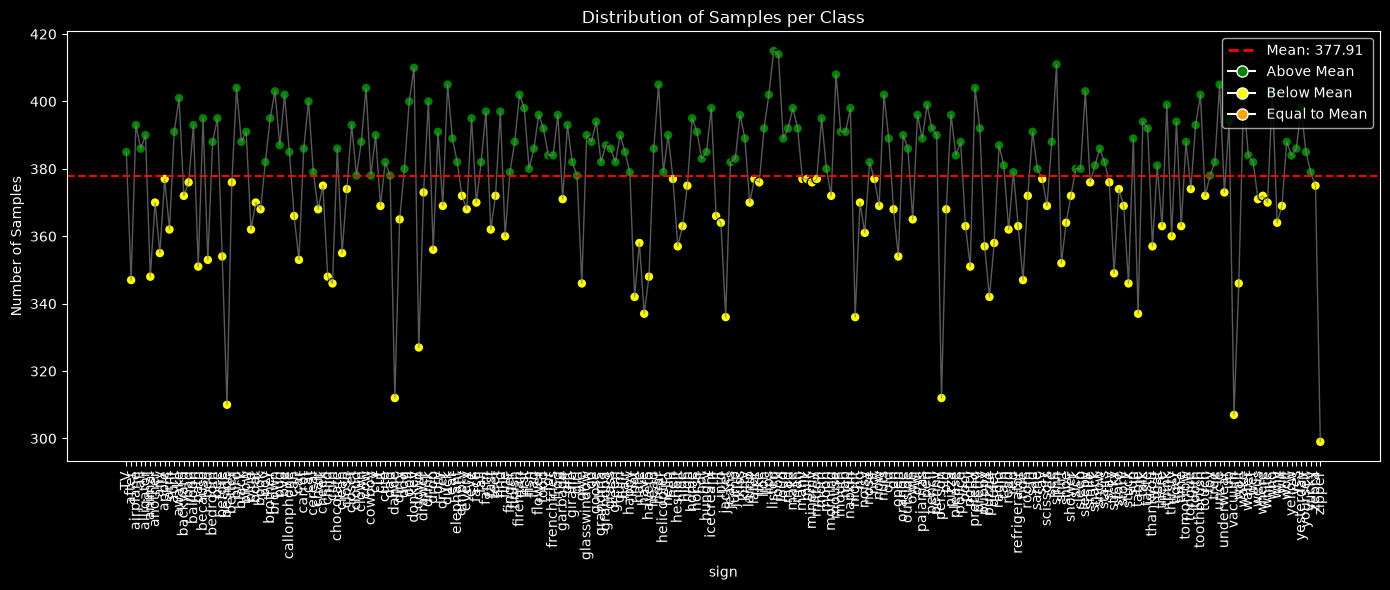

In [3]:
def analyze_label_distribution(
    data: pd.DataFrame,
    label_col: str = "sign",
    title: str = "Distribution of Samples per Class",
    figsize: tuple[int, int] = (14, 6),
    show_plot: bool = True,
):
    """Return class counts and summary stats for any dataframe with a label column."""
    label_distribution = data.groupby(label_col).size().reset_index(name="count")

    counts = label_distribution["count"].values
    labels = label_distribution[label_col].values
    mean_count = counts.mean()

    stats = {
        "mode": label_distribution["count"].mode().iloc[0],
        "std": label_distribution["count"].std(),
        "variance": label_distribution["count"].var(),
        "mean": mean_count,
    }

    print(f"Mode: {stats['mode']}")
    print(f"Standard Deviation: {stats['std']}")
    print(f"Variance: {stats['variance']}")

    if show_plot:
        plt.figure(figsize=figsize)
        x = range(len(labels))

        # Line connecting points
        plt.plot(x, counts, color="gray", linestyle="-", linewidth=1, alpha=0.7)

        # Scatter colored by above/below/equal to mean
        colors = [
            "green" if c > mean_count else ("yellow" if c < mean_count else "orange")
            for c in counts
        ]
        plt.scatter(x, counts, c=colors, s=50, edgecolors="k", label="Sample Count")

        # Mean line
        plt.axhline(y=mean_count, color="r", linestyle="--", label=f"Mean: {mean_count:.2f}")

        plt.title(title)
        plt.xlabel(label_col)
        plt.ylabel("Number of Samples")
        plt.xticks(x, labels, rotation=90)

        # Custom legend
        legend_elements = [
            Line2D([0], [0], color="r", lw=2, linestyle="--", label=f"Mean: {mean_count:.2f}"),
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="green",
                markersize=8,
                label="Above Mean",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="yellow",
                markersize=8,
                label="Below Mean",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="orange",
                markersize=8,
                label="Equal to Mean",
            ),
        ]
        plt.legend(handles=legend_elements, loc="upper right")
        plt.tight_layout()
        plt.show()

    return label_distribution, stats


label_distribution, label_stats = analyze_label_distribution(df)


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df["sign"], random_state=42
)
test_df, val_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["sign"], random_state=42
)

del temp_df


Mode: 306
Standard Deviation: 15.449198520951146
Variance: 238.67773493975906


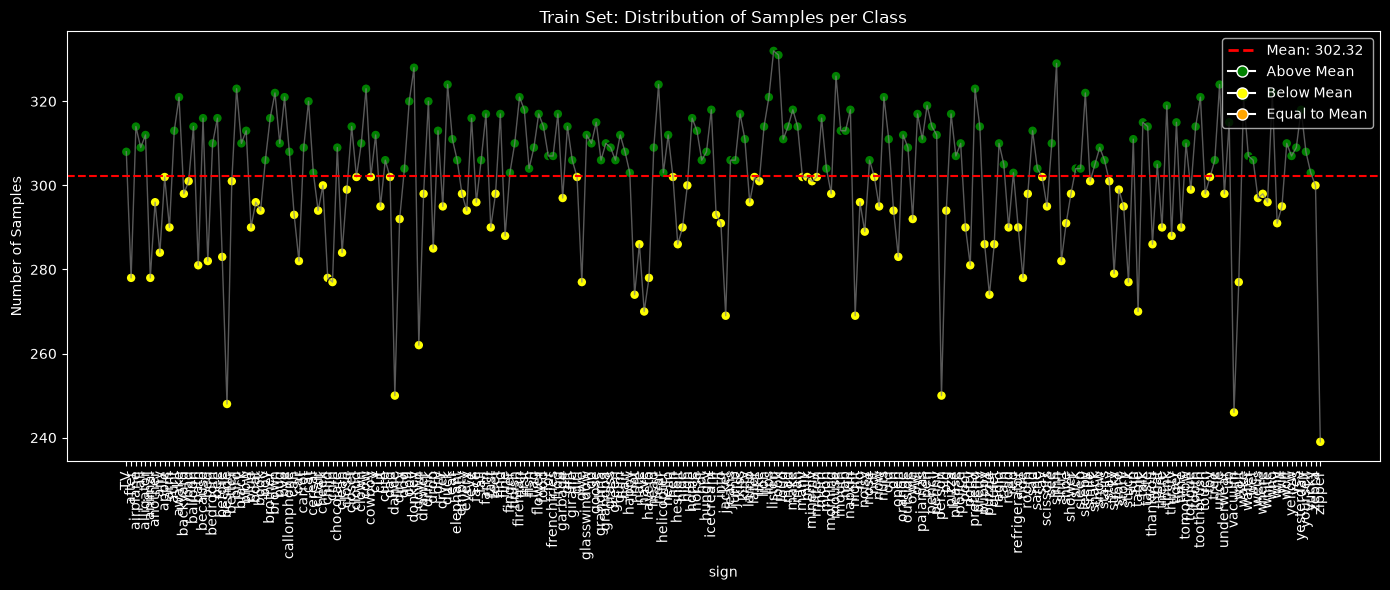

Mode: 38
Standard Deviation: 2.0091997248000375
Variance: 4.036883534136546


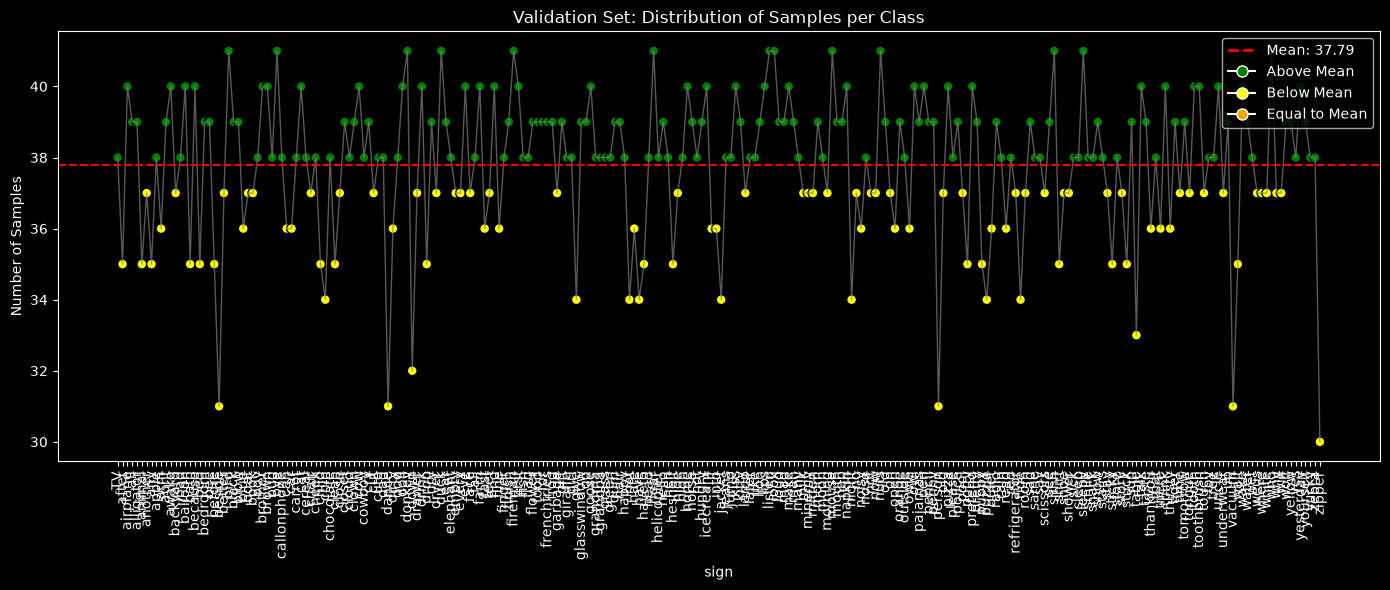

Mode: 39
Standard Deviation: 2.0091997248000375
Variance: 4.036883534136546


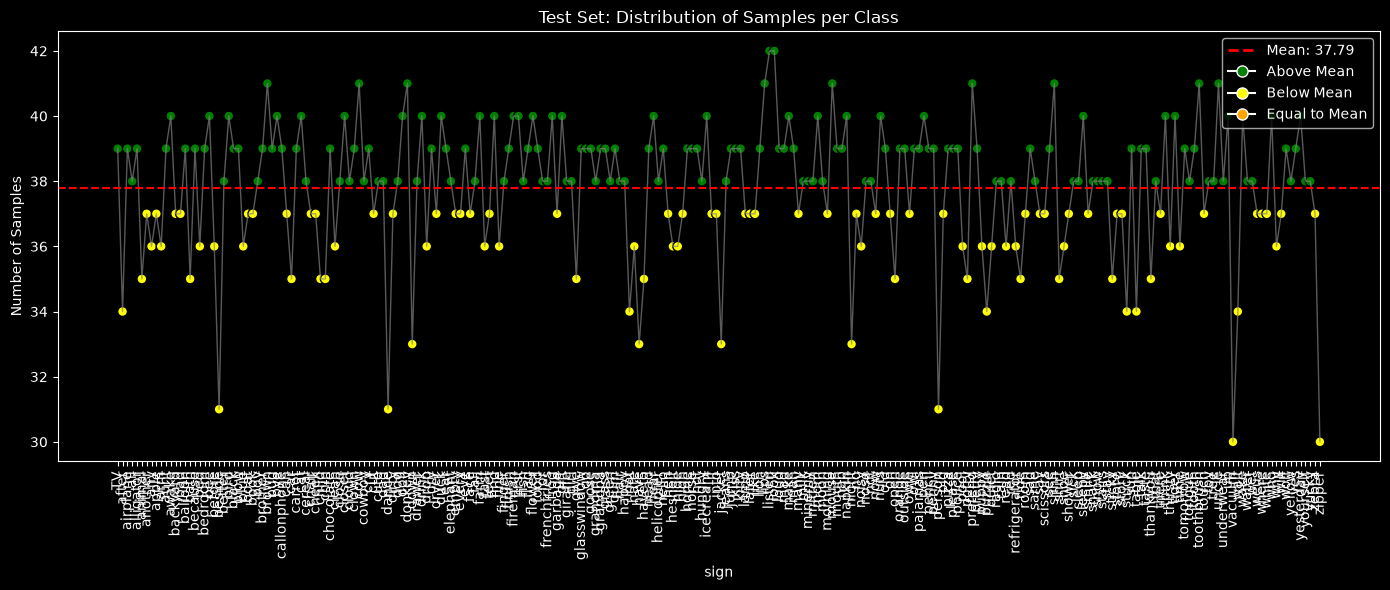

In [6]:
# Statistics for the splits (train, validation, test)

train_label_distribution, train_label_stats = analyze_label_distribution(
    train_df,
    title="Train Set: Distribution of Samples per Class",
)
val_label_distribution, val_label_stats = analyze_label_distribution(
    val_df,
    title="Validation Set: Distribution of Samples per Class",
)
test_label_distribution, test_label_stats = analyze_label_distribution(
    test_df,
    title="Test Set: Distribution of Samples per Class",
)


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# Config
# -----------------------------
DATA_ROOT = ISLR_DATASET
MAX_LEN = 64  # max number of frames per sequence (pad/truncate)
LANDMARK_COUNTS = {
    "left_hand": 21,
    "right_hand": 21,
    "pose": 33,
}  # skip 'face' (468 pts, heavy + less useful)
TOTAL_LANDMARKS = sum(LANDMARK_COUNTS.values())  # 75
N_COORDS = 2  # using x, y only (dropping z, per dataset note)
N_FEATURES = TOTAL_LANDMARKS * N_COORDS
BATCH_SIZE = 64
EPOCHS = 30

# Precompute landmark offsets (so each type occupies a fixed slice in the feature vector)
_offsets = {}
_off = 0
for t, cnt in LANDMARK_COUNTS.items():
    _offsets[t] = _off
    _off += cnt

# -----------------------------
# Label encoding (fit on train_df only, reuse for val/test)
# -----------------------------
le = LabelEncoder()
le.fit(train_df["sign"])
NUM_CLASSES = len(le.classes_)
print(f"Num classes: {NUM_CLASSES}")


# -----------------------------
# Landmark loading / preprocessing
# -----------------------------
def load_and_process(path):
    """Load a single parquet landmark file and convert to a (frames, N_FEATURES) array."""
    df = pd.read_parquet(path, columns=["frame", "type", "landmark_index", "x", "y"])
    df = df[df["type"].isin(LANDMARK_COUNTS.keys())]

    frames = np.sort(df["frame"].unique())
    frame_to_idx = {f: i for i, f in enumerate(frames)}
    n_frames = len(frames)

    seq = np.zeros((n_frames, TOTAL_LANDMARKS, N_COORDS), dtype=np.float32)

    frame_idx = df["frame"].map(frame_to_idx).to_numpy()
    type_offset = df["type"].map(_offsets).to_numpy()
    landmark_idx = type_offset + df["landmark_index"].to_numpy()

    seq[frame_idx, landmark_idx, 0] = df["x"].to_numpy(dtype=np.float32)
    seq[frame_idx, landmark_idx, 1] = df["y"].to_numpy(dtype=np.float32)

    seq = np.nan_to_num(seq)
    seq = seq.reshape(n_frames, -1)  # (frames, N_FEATURES)

    if n_frames >= MAX_LEN:
        seq = seq[:MAX_LEN]
    else:
        pad = np.zeros((MAX_LEN - n_frames, N_FEATURES), dtype=np.float32)
        seq = np.concatenate([seq, pad], axis=0)

    return seq


# -----------------------------
# tf.data generator per split
# -----------------------------
def make_dataset(df, shuffle=False):
    paths = (
        df["path"]
        .apply(lambda p: os.path.normpath(os.path.join(DATA_ROOT, p)))
        .to_numpy()
    )
    labels = le.transform(df["sign"]).astype(np.int32)

    def gen():
        for p, y in zip(paths, labels):
            x = load_and_process(p)
            yield x, y

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(MAX_LEN, N_FEATURES), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int32),
        ),
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=2048, seed=42)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

# -----------------------------
# BiLSTM model
# -----------------------------
model = models.Sequential(
    [
        layers.Input(shape=(MAX_LEN, N_FEATURES)),
        layers.Masking(mask_value=0.0),
        layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
        layers.Dropout(0.3),
        layers.Bidirectional(layers.LSTM(64)),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ]
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

# -----------------------------
# Training
# -----------------------------
early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=5, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
)

# -----------------------------
# Evaluation on held-out test set
# -----------------------------
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")


In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
)

# -----------------------------
# 1. Collect predictions on the test set
# -----------------------------
y_true = []
y_pred = []
y_prob = []

for x_batch, y_batch in test_ds:
    probs = model.predict(x_batch, verbose=0)
    preds = np.argmax(probs, axis=1)
    y_true.extend(y_batch.numpy())
    y_pred.extend(preds)
    y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

class_names = le.classes_  # original sign labels, index-aligned with encoded ints

# -----------------------------
# 2. Overall metrics
# -----------------------------
overall_acc = accuracy_score(y_true, y_pred)
overall_precision_macro = precision_score(
    y_true, y_pred, average="macro", zero_division=0
)
overall_precision_weighted = precision_score(
    y_true, y_pred, average="weighted", zero_division=0
)
overall_recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
overall_f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("===== Overall Metrics =====")
print(f"Accuracy:            {overall_acc:.4f}")
print(f"Precision (macro):   {overall_precision_macro:.4f}")
print(f"Precision (weighted):{overall_precision_weighted:.4f}")
print(f"Recall (macro):      {overall_recall_macro:.4f}")
print(f"F1 (macro):          {overall_f1_macro:.4f}")

# -----------------------------
# 3. Per-class metrics
# -----------------------------
report_dict = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
print("\n===== Per-Class Report (top 20 by support) =====")
print(report_df.sort_values("support", ascending=False).head(20))

# Save full per-class report if you want to inspect all classes
# report_df.to_csv("per_class_metrics.csv")  # optional, uncomment if needed

# -----------------------------
# 4. Confusion matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

# If you have many classes, plotting the full matrix will be unreadable.
# Option A: full matrix (only good for a small number of classes)
if len(class_names) <= 30:
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    # Option B: show only the top-N most confused class pairs
    N = 20
    cm_no_diag = cm.copy().astype(float)
    np.fill_diagonal(cm_no_diag, 0)
    top_confusions = np.dstack(
        np.unravel_index(np.argsort(-cm_no_diag.ravel()), cm_no_diag.shape)
    )[0][:N]

    print(f"\n===== Top {N} Confused Class Pairs (true -> predicted, count) =====")
    for i, j in top_confusions:
        if cm_no_diag[i, j] > 0:
            print(f"{class_names[i]:20s} -> {class_names[j]:20s} : {int(cm[i, j])}")

# -----------------------------
# 5. Latency benchmark (single-sample inference)
# -----------------------------
# Grab a batch of real samples to benchmark on
sample_batch = None
for x_batch, _ in test_ds.take(1):
    sample_batch = x_batch.numpy()
    break

n_warmup = 5
n_runs = 100
single_sample = sample_batch[0:1]  # shape (1, MAX_LEN, N_FEATURES)

# Warmup (important for TF graph tracing / XLA)
for _ in range(n_warmup):
    _ = model.predict(single_sample, verbose=0)

latencies = []
for _ in range(n_runs):
    start = time.perf_counter()
    _ = model.predict(single_sample, verbose=0)
    end = time.perf_counter()
    latencies.append((end - start) * 1000)  # ms

latencies = np.array(latencies)
print("\n===== Latency (single-sample, model.predict) =====")
print(f"Mean:   {latencies.mean():.2f} ms")
print(f"Median: {np.median(latencies):.2f} ms")
print(f"P95:    {np.percentile(latencies, 95):.2f} ms")
print(f"P99:    {np.percentile(latencies, 99):.2f} ms")
print(f"Min:    {latencies.min():.2f} ms")
print(f"Max:    {latencies.max():.2f} ms")

# -----------------------------
# 6. Throughput benchmark (batch inference)
# -----------------------------
batch_size_bench = BATCH_SIZE
bench_batch = (
    sample_batch
    if sample_batch.shape[0] >= batch_size_bench
    else np.tile(sample_batch, (batch_size_bench // sample_batch.shape[0] + 1, 1, 1))[
        :batch_size_bench
    ]
)

for _ in range(n_warmup):
    _ = model.predict(bench_batch, verbose=0)

start = time.perf_counter()
n_batches = 20
for _ in range(n_batches):
    _ = model.predict(bench_batch, verbose=0)
end = time.perf_counter()

total_samples = n_batches * batch_size_bench
throughput = total_samples / (end - start)
print("\n===== Throughput =====")
print(f"{throughput:.1f} samples/sec (batch size {batch_size_bench})")
